##### Forest

The goal of this file is to implement a random forest model. 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


In [3]:
# Columns for reference
columns = ['id', 'title', 'release_date', 'un_profitability', 'vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity', 
           'actor_avg', 'actor_med', 'actor_dev', 'production_avg', 'production_med', 'production_dev', 
           'release_year', 'release_month', 'original_title_matches', 'profit', 'original_language_english', 
           'american_film', 'english_language']


In [4]:
df = pd.read_csv('movie-data/cleaned_analysis_data.csv')

df = df.drop(columns=['id'])

# Drop columns that are directly related to profitability
df = df.drop(columns=['budget', 'profit', 'revenue'])

# Drop columns that are not encoded
df = df.drop(columns=["title", "release_date"])

In [5]:
# y is what we are predicting.
# x are the features.
Y = df['un_profitability']
X = df.drop(columns=['un_profitability'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=9)


In [6]:
# Define and instantiate the Random Forest model with key parameters
num_trees = 200      # Number of trees in the forest
max_depth = 20       # Maximum depth of each tree; adjust as needed
seed = 9             # Seed for reproducibility
weight = 'balanced'  # Handle imbalance by weighting classes

rf_model = RandomForestClassifier(n_estimators=num_trees,
                                  max_depth=max_depth,
                                  random_state=seed,
                                  class_weight=weight)


In [7]:
rf_model.fit(X_train, Y_train)
Y_predictions = rf_model.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(Y_test, Y_predictions)
print("Confusion Matrix: \n", conf_matrix)

print("\nClassification Report:")
print(classification_report(Y_test, Y_predictions, zero_division=0))

print("Accuracy: ", accuracy_score(Y_test, Y_predictions))
print("Precision: ", precision_score(Y_test, Y_predictions))
print("Recall: ", recall_score(Y_test, Y_predictions))
print("F1: ", f1_score(Y_test, Y_predictions))

# Display additional metrics: number of correct predictions out of total predictions
correct_predictions = (Y_test == Y_predictions).sum()
total_predictions = len(Y_test)
print(f"\nCorrectly predicted {correct_predictions} out of {total_predictions} instances")

Confusion Matrix: 
 [[3084  183]
 [ 613 1170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      3267
           1       0.86      0.66      0.75      1783

    accuracy                           0.84      5050
   macro avg       0.85      0.80      0.82      5050
weighted avg       0.84      0.84      0.84      5050

Accuracy:  0.8423762376237623
Precision:  0.8647450110864745
Recall:  0.6561974200785193
F1:  0.7461734693877551

Correctly predicted 4254 out of 5050 instances


In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# Set up Stratified 10-fold cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=9)

# Define the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=9,
    class_weight='balanced'
)

# Compute scores
accuracy_scores = cross_val_score(rf_model, X, Y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(rf_model, X, Y, cv=cv, scoring='f1')
precision_scores = cross_val_score(rf_model, X, Y, cv=cv, scoring='precision')
recall_scores = cross_val_score(rf_model, X, Y, cv=cv, scoring='recall')

# Print all results
print(f"Accuracy : {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")
print(f"F1 Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"Precision: {precision_scores.mean():.4f} ± {precision_scores.std():.4f}")
print(f"Recall   : {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")

Accuracy : 0.8322 ± 0.0058
F1 Score : 0.7334 ± 0.0102
Precision: 0.8244 ± 0.0096
Recall   : 0.6606 ± 0.0131


In [23]:
# Trying to get a range of values and how the accuracy and f1 score change.

# Define a parameter grid for the Random Forest model.
param_grid_rf = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300],  # Number of trees in the forest.
    'max_depth': [5, 20, 25, 100],  # Maximum depth of each tree.
    'class_weight': ['balanced']              # Handle class imbalance.
}

rf = RandomForestClassifier(random_state=9)

# Set up GridSearchCV with 5-fold cross-validation.
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, 
                              scoring={"Accuracy": "accuracy", "F1":"f1"}, 
                              refit="F1", n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, Y_train)

# Output the best parameters and best cross-validation score.
print("Best Parameters for Random Forest Grid Search:")
print(grid_search_rf.best_params_)
print("\nBest CV Score:")
print(grid_search_rf.best_score_)

# Evaluate the best estimator on the test set.
best_rf = grid_search_rf.best_estimator_
Y_pred_rf = best_rf.predict(X_test)
print("\nClassification Report for the Grid Search Optimized Random Forest:")
print(classification_report(Y_test, Y_pred_rf, zero_division=0))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters for Random Forest Grid Search:
{'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 200}

Best CV Score:
0.7220239963389369

Classification Report for the Grid Search Optimized Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      3267
           1       0.84      0.68      0.75      1783

    accuracy                           0.84      5050
   macro avg       0.84      0.80      0.82      5050
weighted avg       0.84      0.84      0.84      5050



In [24]:
# Results DataFrame
results_df = pd.DataFrame(grid_search_rf.cv_results_)

# Only select the columns we care about
scores_df = results_df[['param_n_estimators', 'param_max_depth', 'param_class_weight', 
                        'mean_test_Accuracy', 'mean_test_F1']]

In [25]:
print(scores_df.shape)
pd.set_option('display.max_columns', None)
print(scores_df.sort_values(by="mean_test_Accuracy"))

(36, 5)
    param_n_estimators  param_max_depth param_class_weight  \
0                   10                5           balanced   
1                   25                5           balanced   
3                   75                5           balanced   
2                   50                5           balanced   
4                  100                5           balanced   
5                  150                5           balanced   
6                  200                5           balanced   
7                  250                5           balanced   
8                  300                5           balanced   
9                   10               20           balanced   
18                  10               25           balanced   
27                  10              100           balanced   
10                  25               20           balanced   
28                  25              100           balanced   
19                  25               25           balanced   


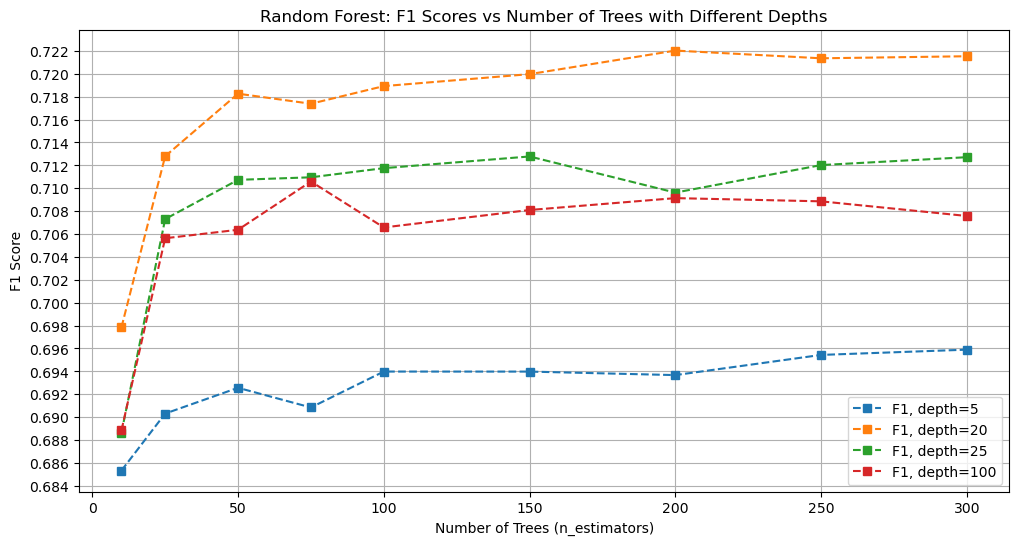

In [26]:
plt.figure(figsize=(12,6))

for depth in [5, 20, 25, 100]:
    subset = scores_df[scores_df['param_max_depth'] == depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_F1'], marker='s', linestyle='--', label=f'F1, depth={depth}')

plt.title('Random Forest: F1 Scores vs Number of Trees with Different Depths')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()
plt.locator_params(axis='y', nbins=30)
plt.show()

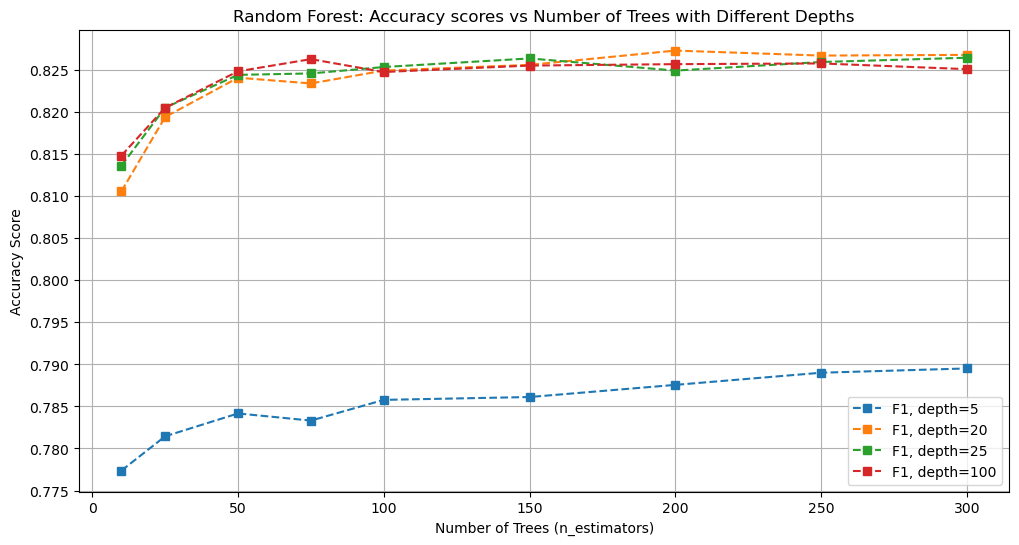

In [28]:
plt.figure(figsize=(12,6))

for depth in [5, 20, 25, 100]:
    subset = scores_df[scores_df['param_max_depth'] == depth]
    plt.plot(subset['param_n_estimators'], subset['mean_test_Accuracy'], marker='s', linestyle='--', label=f'F1, depth={depth}')

plt.title('Random Forest: Accuracy scores vs Number of Trees with Different Depths')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.legend()
plt.locator_params(axis='y', nbins=20)
plt.show()


### Discovering Features with most impact.

In [38]:
# y is what we are predicting.
# x are the features.
Y = df['un_profitability']
X = df.drop(columns=['un_profitability'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=9)

feature_list = X_train.columns.tolist()
feature_performance = []

# Define and instantiate the Random Forest model with key parameters
num_trees = 200      # Number of trees in the forest
max_depth = 20       # Maximum depth of each tree; adjust as needed
seed = 9             # Seed for reproducibility
weight = 'balanced'  # Handle imbalance by weighting classes
rf_model = RandomForestClassifier(n_estimators=num_trees,
                                  max_depth=max_depth,
                                  random_state=seed,
                                  class_weight=weight)

rf_model.fit(X_train, Y_train)
Y_predictions = rf_model.predict(X_test)

baseline_accuracy = accuracy_score(Y_test, Y_predictions)
baseline_f1 = f1_score(Y_test, Y_predictions)

print("accuracy: ", baseline_accuracy)
print("f1: ", baseline_f1)

print("\nBaseline:")
print(classification_report(Y_test, Y_predictions, zero_division=0))


for feature in feature_list:
    reduced_features = [f for f in feature_list if f != feature]
    X_train_reduced = X_train[reduced_features]
    X_test_reduced = X_test[reduced_features]

    rf_model = RandomForestClassifier(n_estimators=num_trees, max_depth=max_depth, random_state=seed, class_weight=weight)
    
    rf_model.fit(X_train_reduced, Y_train)
    Y_predictions_reduced = rf_model.predict(X_test_reduced)

    accuracy = accuracy_score(Y_test, Y_predictions_reduced)
    f1 = f1_score(Y_test, Y_predictions_reduced)
    feature_performance.append((feature, accuracy, f1))

performance_df = pd.DataFrame(feature_performance, columns=['Feature_Removed', 'Accuracy_Score_After_Removal', 'F1_Score_After_Removal'])

# Calculate Accuracy Drop
performance_df['Accuracy_Drop'] = baseline_accuracy - performance_df['Accuracy_Score_After_Removal']
# Calculate F1 Drop
performance_df['F1_Drop'] = baseline_f1 - performance_df['F1_Score_After_Removal']

# Sort by largest Accuracy drop
performance_df = performance_df.sort_values('Accuracy_Drop', ascending=False)
print("\nFeature Importance Based on Accuracy  Drop:")
print(performance_df.head(5))

# Sort by largest F1 drop
performance_df = performance_df.sort_values('F1_Drop', ascending=False)
print("\nFeature Importance Based on F1 Drop:")
print(performance_df.head(5))


accuracy:  0.8413861386138614
f1:  0.751781840718934

Baseline:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      3267
           1       0.84      0.68      0.75      1783

    accuracy                           0.84      5050
   macro avg       0.84      0.80      0.82      5050
weighted avg       0.84      0.84      0.84      5050


Feature Importance Based on Accuracy  Drop:
   Feature_Removed  Accuracy_Score_After_Removal  F1_Score_After_Removal  \
5        actor_med                      0.819406                0.712665   
8   production_med                      0.824950                0.726316   
10    release_year                      0.830891                0.736094   
9   production_dev                      0.831485                0.737265   
6        actor_dev                      0.833069                0.737138   

    Accuracy_Drop   F1_Drop  
5        0.021980  0.039116  
8        0.016436  0.025466  
10       0.010495

In [37]:
performance_df = performance_df.sort_values('Accuracy_Drop', ascending=True)
print("\nLeast Important Features Based on Accuracy Drop:")
print(performance_df.head(5))


Least Important Features Based on Accuracy Drop:
              Feature_Removed  Accuracy_Score_After_Removal  \
11              release_month                      0.844356   
14              american_film                      0.843366   
3                  popularity                      0.841782   
15           english_language                      0.841386   
13  original_language_english                      0.840594   

    F1_Score_After_Removal  Accuracy_Drop   F1_Drop  
11                0.757707      -0.002970 -0.005925  
14                0.755184      -0.001980 -0.003402  
3                 0.753167      -0.000396 -0.001385  
15                0.751936       0.000000 -0.000154  
13                0.750697       0.000792  0.001085  
